In [1]:
import pandas as pd
import ast

In [2]:
#load in speech metadata
speech_metadata = pd.read_csv("../../data/clean/speech_metadata/kokkai_metadata.csv")


In [3]:
#convert speech_metadata dates and filter to 2012-2024
speech_metadata['date'] = pd.to_datetime(speech_metadata['date'], format = '%Y-%m-%d')
speech_metadata_2012_2024 = speech_metadata.query('date >= "2012-01-01" and date <= "2024-12-31"')
speech_metadata_2012_2024.head()

,speechID,session,nameOfHouse,nameOfMeeting,issue,date,year,speaker,speakerYomi,speakerGroup,speakerPosition,speakerRole,speechURL,meetingURL,pdfURL,keywords_matched,num_keywords
197,121614889X00320241219_027,216,参議院,内閣委員会,第3号,2024-12-19,2024,上月良祐,こうづきりょうすけ,自由民主党,NaN,NaN,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/img/121614889X0032024...,"['特定技能', '技能実習']",2
198,121614889X00320241219_029,216,参議院,内閣委員会,第3号,2024-12-19,2024,上月良祐,こうづきりょうすけ,自由民主党,NaN,NaN,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/img/121614889X0032024...,['特定技能'],1
199,121615007X00220241219_270,216,参議院,農林水産委員会,第2号,2024-12-19,2024,松本平,NaN,NaN,農林水産省畜産局長,NaN,https://kokkai.ndl.go.jp/txt/121615007X0022024...,https://kokkai.ndl.go.jp/txt/121615007X0022024...,https://kokkai.ndl.go.jp/img/121615007X0022024...,"['特定技能', '外国人材', '技能実習']",3
200,121615206X00320241219_188,216,参議院,法務委員会,第3号,2024-12-19,2024,川合孝典,かわいたかのり,国民民主党・新緑風会,NaN,NaN,https://kokkai.ndl.go.jp/txt/121615206X0032024...,https://kokkai.ndl.go.jp/txt/121615206X0032024...,https://kokkai.ndl.go.jp/img/121615206X0032024...,"['特定技能', '技能実習', '技能実習生']",3
201,121615206X00320241219_189,216,参議院,法務委員会,第3号,2024-12-19,2024,杉山徳明,NaN,NaN,出入国在留管理庁次長,NaN,https://kokkai.ndl.go.jp/txt/121615206X0032024...,https://kokkai.ndl.go.jp/txt/121615206X0032024...,https://kokkai.ndl.go.jp/img/121615206X0032024...,['特定技能'],1


In [4]:
#convert the keywords matched from string to list object
speech_metadata_2012_2024['keywords_matched'] = speech_metadata_2012_2024['keywords_matched'].dropna().apply(ast.literal_eval)

In [ ]:
#explode the data on keywords to make it easier to count
kw_explode = speech_metadata_2012_2024.explode('keywords_matched')
kw_explode.head()

,speechID,session,nameOfHouse,nameOfMeeting,issue,date,year,speaker,speakerYomi,speakerGroup,speakerPosition,speakerRole,speechURL,meetingURL,pdfURL,keywords_matched,num_keywords
197,121614889X00320241219_027,216,参議院,内閣委員会,第3号,2024-12-19,2024,上月良祐,こうづきりょうすけ,自由民主党,NaN,NaN,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/img/121614889X0032024...,特定技能,2
197,121614889X00320241219_027,216,参議院,内閣委員会,第3号,2024-12-19,2024,上月良祐,こうづきりょうすけ,自由民主党,NaN,NaN,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/img/121614889X0032024...,技能実習,2
198,121614889X00320241219_029,216,参議院,内閣委員会,第3号,2024-12-19,2024,上月良祐,こうづきりょうすけ,自由民主党,NaN,NaN,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/txt/121614889X0032024...,https://kokkai.ndl.go.jp/img/121614889X0032024...,特定技能,1
199,121615007X00220241219_270,216,参議院,農林水産委員会,第2号,2024-12-19,2024,松本平,NaN,NaN,農林水産省畜産局長,NaN,https://kokkai.ndl.go.jp/txt/121615007X0022024...,https://kokkai.ndl.go.jp/txt/121615007X0022024...,https://kokkai.ndl.go.jp/img/121615007X0022024...,特定技能,3
199,121615007X00220241219_270,216,参議院,農林水産委員会,第2号,2024-12-19,2024,松本平,NaN,NaN,農林水産省畜産局長,NaN,https://kokkai.ndl.go.jp/txt/121615007X0022024...,https://kokkai.ndl.go.jp/txt/121615007X0022024...,https://kokkai.ndl.go.jp/img/121615007X0022024...,外国人材,3


In [69]:
#group by year and count keywords
counts_by_year = kw_explode.groupby('year')['keywords_matched'].value_counts()
unstacked = counts_by_year.unstack(level = 'keywords_matched').fillna(0)
unstacked.describe()

keywords_matched,不法滞在,入管政策,出入国管理,外国人住民,外国人労働力,外国人労働者,外国人受け入れ,外国人支援,外国人材,外国人材確保,外国人犯罪,外国人雇用,多文化共生,技能実習,技能実習生,特定技能,移民受け入れ,移民政策,高度外国人材
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,23.692308,0.538462,119.384615,10.769231,4.846154,140.692308,3.538462,5.769231,136.538462,0.307692,3.769231,8.615385,29.307692,472.384615,277.615385,164.692308,0.230769,26.076923,7.692308
std,14.890627,0.877058,67.592577,5.804508,6.066934,151.234026,5.695252,7.189736,161.512443,0.751068,3.443686,10.897541,28.778999,458.192197,273.546930,251.232092,0.599145,31.049588,7.040178
min,7.000000,0.000000,18.000000,4.000000,0.000000,7.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,3.000000,4.000000,2.000000,0.000000,0.000000,2.000000,0.000000
25%,9.000000,0.000000,50.000000,7.000000,2.000000,50.000000,0.000000,1.000000,37.000000,0.000000,1.000000,2.000000,5.000000,219.000000,128.000000,0.000000,0.000000,8.000000,3.000000
50%,18.000000,0.000000,125.000000,10.000000,2.000000,83.000000,1.000000,3.000000,93.000000,0.000000,3.000000,4.000000,20.000000,262.000000,149.000000,45.000000,0.000000,14.000000,3.000000
75%,35.000000,1.000000,177.000000,14.000000,5.000000,108.000000,4.000000,8.000000,149.000000,0.000000,5.000000,9.000000,41.000000,823.000000,466.000000,162.000000,0.000000,30.000000,15.000000
max,49.000000,3.000000,222.000000,23.000000,19.000000,519.000000,16.000000,25.000000,561.000000,2.000000,11.000000,35.000000,87.000000,1389.000000,804.000000,710.000000,2.000000,112.000000,20.000000


In [ ]:
#filter the keyword count data to remove words with a mean count < 30
unstacked_means = unstacked.mean()
unstacked_filtered = unstacked.loc[:, unstacked_means > 30]

#import speech keywords translation dictionary and change column names
#add path one up from current directory to be able to find references folder
import sys
from pathlib import Path
repo_root = Path.cwd().resolve().parents[1]
sys.path.append(str(repo_root))

#import and translate column names
from references.dictionaries.speech_keywords import speech_keywords_to_eng
unstacked_filtered = unstacked_filtered.rename(columns=speech_keywords_to_eng)
unstacked_filtered.head()

keywords_matched,Immigration control,Foreign workers,Foreign human resources,Technical intern training,Technical intern trainees,Specified Skilled Worker (SSW)
year,,,,,,
2012,18.0,7.0,2.0,4.0,2.0,0.0
2013,34.0,33.0,2.0,36.0,23.0,0.0
2014,160.0,108.0,95.0,313.0,128.0,1.0
2015,49.0,64.0,32.0,219.0,115.0,0.0
2016,177.0,104.0,93.0,1256.0,776.0,0.0


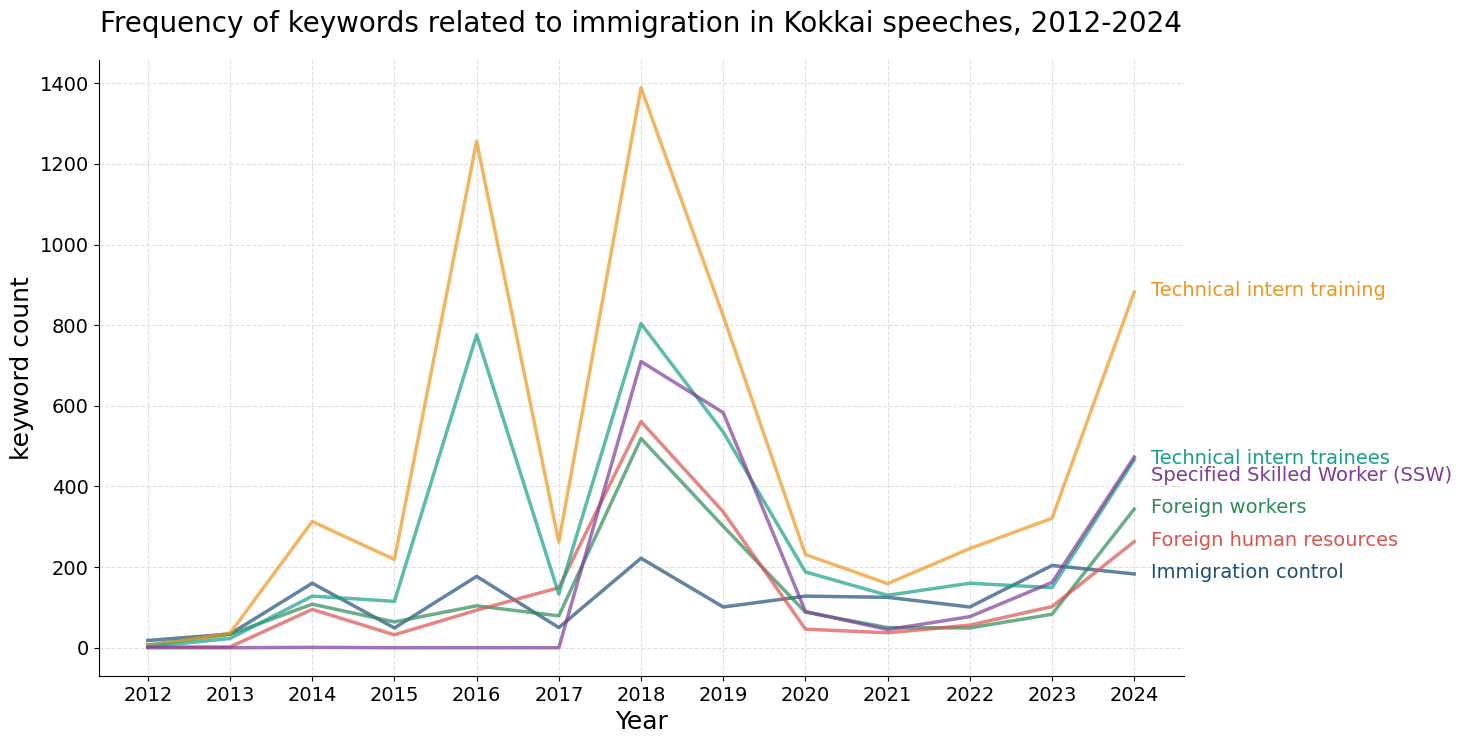

In [106]:
#plot the filtered keywords usage over time 
import matplotlib.pyplot as plt

palette = [
    '#1F4E79',  # Deep Steel Blue
    '#2E8B57',  # Sea Green
    '#D9534F',  # Soft Coral/Red
    '#EC971F',  # Muted Amber/Gold
    '#16A085',  # Dark Teal
    '#7D3C98'   # Soft Plum/Purple
]

fig, ax = plt.subplots(figsize=(14,8))
for i, column in enumerate(unstacked_filtered.columns):
    ax.plot(unstacked_filtered.index,
            unstacked_filtered[column],
            color = palette[i],
            linewidth = 2.5,
            alpha = 0.7)
    ax.text(unstacked_filtered.index[-1] + 0.2,
            unstacked_filtered[column].iloc[-1] -60 if column == 'Specified Skilled Worker (SSW)' else unstacked_filtered[column].iloc[-1]-10,
            s = column,
            color = palette[i],
            fontsize = 14)
    
ax.set_xticks(list(range(2012,2025)))
ax.tick_params(axis='both', labelsize = 14)
ax.set_xlabel('Year', fontsize = 18)
ax.set_ylabel('keyword count', fontsize = 18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(
    visible=True,      
    which='major',     
    color='#e0e0e0',   
    linestyle='--',     
    linewidth=0.8,     
)
ax.set_title('Frequency of keywords related to immigration in Kokkai speeches, 2012-2024',
             fontsize= 20,
             pad = 20)
#plt.show()
plt.savefig('../../data/figures/kokkai_keywords_frequency.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)


In [91]:
unstacked_filtered['Foreign human resources'].iloc[-1]

263.0